# The same house in different areas

What the same house would be assessed at in each of the 21 areas, according to the production models.

**Method** (`evaluating.same_house_by_area`; run `uv run python -m src.components.evaluating same_house_by_area`
first, it writes the two CSVs this notebook reads):

- A **reference house** keeps its own house features (type, size, rooms, age, lot). The reference houses are the
  config test addresses and the typical single-family house, townhouse and condo: the real house closest to the
  median of its type.
- In each area, the house is given the **location of 300 real parcels of the same type**: every non-house feature
  from one parcel at a time (area, coordinates, neighborhood features, accessibility, schools, crime, flood, rail),
  so each combination is one that exists.
- **Premium**: the house's mean log estimate in the area against the same house with 3,000 county-wide parcels'
  locations, as a percent. +20% means the same house is assessed about 20% higher there than in a typical
  county location.
- **Size coverage**: the share of donors whose neighborhood has a house of the same type within 25% of the
  reference house's size. Below about 50%, the model is valuing a house unlike any around it.
- **Raw-data check**: the area's median assessed value per sq ft for houses of the same type within 20% of the
  size, against the county's. No model is involved.
- **Decomposition** (`evaluating.area_premium_decomposition`, without-neighborhood-price model, typical houses
  only): Shapley values over location groups. Each area donor is paired with a county donor, and each group's
  share is its average effect when switched from the county donor's value to the area donor's. The shares add up
  to the premium in log terms.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

from src.components.evaluating import DECOMPOSITION_GROUPS
from src.utils.common import resolve_path
from src.utils.load_config import load_config

reports = Path(resolve_path(load_config(), "reports"))
by_area = pd.read_csv(reports / "same_house_by_area.csv")
decomposition = pd.read_csv(reports / "area_premium_decomposition.csv")

# reference palette: diverging red <-> gray <-> blue, categorical slots in fixed order
BLUE, RED, MID = "#2a78d6", "#e34948", "#f0efec"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
INK, MUTED = "#0b0b0b", "#52514e"
DIVERGING = LinearSegmentedColormap.from_list("premium", [RED, MID, BLUE])
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": MUTED,
                     "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.6, "axes.axisbelow": True})
MODEL = "without_neighborhood_price"  # the model to read for what location is worth

## The typical single-family house in each area

The typical house is a real 2,125 sq ft, 3-bedroom, 2.5-bath house built in 1996 on 0.27 acres. Bars are the
model's premium. Dots are the raw-data check.

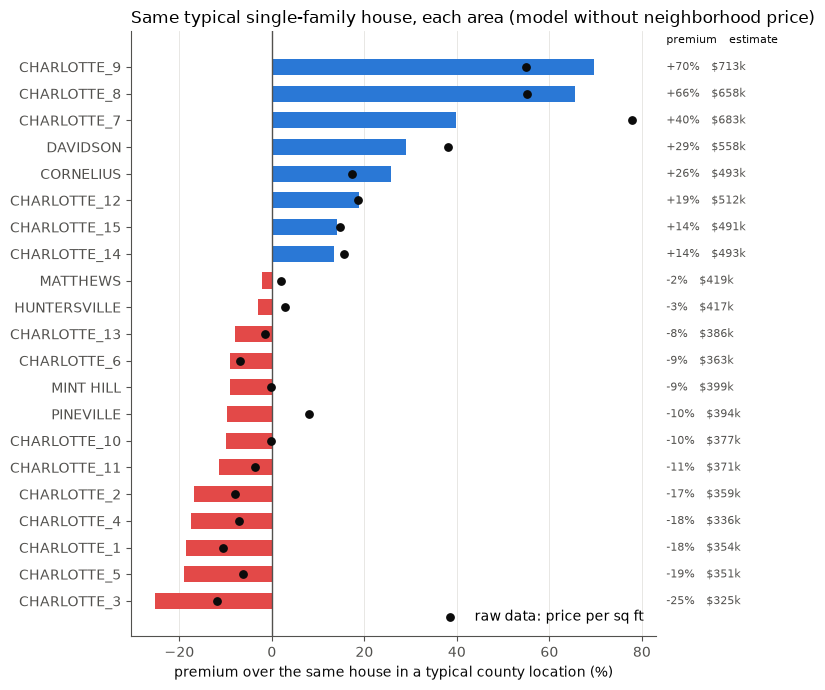

correlation, model premium vs raw-data premium: {('3612 Abbey Hill Ln', 'with_neighborhood_price'): 0.93, ('3612 Abbey Hill Ln', 'without_neighborhood_price'): 0.91, ('4817 Kelly Woods Ln', 'with_neighborhood_price'): 0.93, ('4817 Kelly Woods Ln', 'without_neighborhood_price'): 0.94, ('7631 Seton House Ln', 'with_neighborhood_price'): 0.92, ('7631 Seton House Ln', 'without_neighborhood_price'): 0.91, ('typical condo', 'with_neighborhood_price'): 0.95, ('typical condo', 'without_neighborhood_price'): 0.94, ('typical single_family', 'with_neighborhood_price'): 0.92, ('typical single_family', 'without_neighborhood_price'): 0.92, ('typical townhouse', 'with_neighborhood_price'): 0.89, ('typical townhouse', 'without_neighborhood_price'): 0.88}


,area,estimate,estimate_p10,estimate_p90,premium,raw_premium,size_coverage
155,CHARLOTTE_3,325297.779,303476.467,352485.946,-0.253,-0.119,0.987
157,CHARLOTTE_5,350835.091,329201.431,390115.635,-0.190,-0.063,1.000
147,CHARLOTTE_1,354341.870,329172.816,383534.195,-0.185,-0.105,0.997
156,CHARLOTTE_4,336139.583,297152.742,502920.954,-0.175,-0.071,0.970
154,CHARLOTTE_2,359078.671,337171.127,396783.867,-0.169,-0.081,0.997
149,CHARLOTTE_11,371112.446,349774.866,470405.637,-0.114,-0.037,0.977
148,CHARLOTTE_10,376966.924,341948.555,487938.857,-0.098,-0.001,1.000
167,PINEVILLE,394156.567,373642.786,414225.632,-0.097,0.081,1.000
166,MINT HILL,398689.385,358848.361,435412.396,-0.091,-0.001,0.970
158,CHARLOTTE_6,362600.897,311551.495,615438.334,-0.090,-0.069,0.993


In [2]:
house = "typical single_family"
rows = by_area[(by_area["house"] == house) & (by_area["feature_set"] == MODEL)].sort_values("premium")
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(rows["area"], rows["premium"] * 100, color=np.where(rows["premium"] >= 0, BLUE, RED), height=0.6)
ax.scatter(rows["raw_premium"] * 100, rows["area"], color=INK, s=28, zorder=3, label="raw data: price per sq ft")
# labels in a column right of the plot, so they never collide with bars, dots or area names
for y, (p, est) in enumerate(zip(rows["premium"], rows["estimate"])):
    ax.text(1.02, y, f"{p:+.0%}   ${est / 1000:,.0f}k", transform=ax.get_yaxis_transform(),
            va="center", fontsize=8, color=MUTED)
ax.text(1.02, len(rows), "premium   estimate", transform=ax.get_yaxis_transform(), va="center", fontsize=8, color=INK)
ax.axvline(0, color=MUTED, linewidth=1)
ax.set_xlabel("premium over the same house in a typical county location (%)")
ax.set_title("Same typical single-family house, each area (model without neighborhood price)", loc="left")
ax.legend(loc="lower right", frameon=False)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print("correlation, model premium vs raw-data premium:",
      by_area.groupby(["house", "feature_set"]).apply(lambda g: g["premium"].corr(g["raw_premium"])).round(2).to_dict())
rows[["area", "estimate", "estimate_p10", "estimate_p90", "premium", "raw_premium", "size_coverage"]].round(3)

## Every reference house

Premium per reference house and area. Cells marked `*` have size coverage below 50%: few houses of that size
nearby, so the number is an extrapolation.

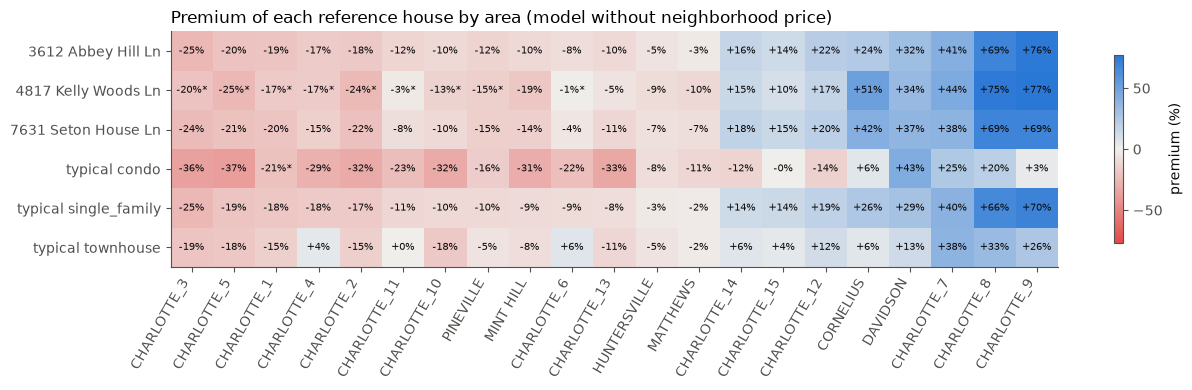

In [3]:
grid = by_area[by_area["feature_set"] == MODEL].pivot(index="house", columns="area", values="premium")
coverage = by_area[by_area["feature_set"] == MODEL].pivot(index="house", columns="area", values="size_coverage")
order = grid.loc["typical single_family"].sort_values().index
grid, coverage = grid[order], coverage[order]
fig, ax = plt.subplots(figsize=(13, 4))
limit = np.abs(grid.to_numpy()).max()
image = ax.imshow(grid * 100, cmap=DIVERGING, norm=TwoSlopeNorm(0, -limit * 100, limit * 100), aspect="auto")
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        flag = "*" if coverage.iat[i, j] < 0.5 else ""
        ax.text(j, i, f"{grid.iat[i, j]:+.0%}{flag}", ha="center", va="center", fontsize=7, color=INK)
ax.set_xticks(range(grid.shape[1]), grid.columns, rotation=60, ha="right")
ax.set_yticks(range(grid.shape[0]), grid.index)
ax.grid(False)
fig.colorbar(image, ax=ax, label="premium (%)", shrink=0.8)
ax.set_title("Premium of each reference house by area (model without neighborhood price)", loc="left")
plt.tight_layout()
plt.show()

### With and without the neighborhood price

How much the two production models disagree about each area's premium for the typical single-family house.

In [4]:
both = (by_area[by_area["house"] == "typical single_family"]
        .pivot(index="area", columns="feature_set", values="premium").sort_values(MODEL))
both["difference"] = both["with_neighborhood_price"] - both[MODEL]
both.round(3)

feature_set,with_neighborhood_price,without_neighborhood_price,difference
area,,,
CHARLOTTE_3,-0.250,-0.253,0.003
CHARLOTTE_5,-0.195,-0.190,-0.006
CHARLOTTE_1,-0.193,-0.185,-0.008
CHARLOTTE_4,-0.153,-0.175,0.023
CHARLOTTE_2,-0.173,-0.169,-0.004
CHARLOTTE_11,-0.106,-0.114,0.008
CHARLOTTE_10,-0.098,-0.098,0.001
PINEVILLE,-0.102,-0.097,-0.006
MINT HILL,-0.094,-0.091,-0.003


## Where each area's premium comes from

Shapley shares of the premium for the typical single-family house, in log value (0.10 is about 10%). Positive
shares stack to the right of zero and negative ones to the left. The black tick is the total.

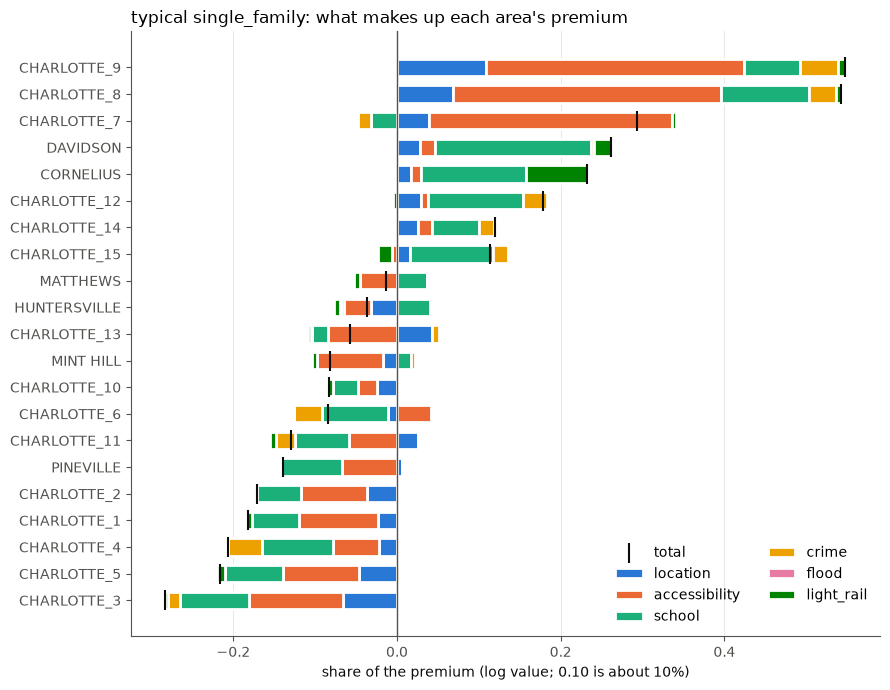

,premium,log_premium,location_log,accessibility_log,school_log,crime_log,flood_log,light_rail_log
area,,,,,,,,
CHARLOTTE_3,-0.247,-0.283,-0.065,-0.116,-0.084,-0.015,0.000,-0.004
CHARLOTTE_5,-0.194,-0.216,-0.046,-0.093,-0.070,0.003,0.000,-0.010
CHARLOTTE_4,-0.187,-0.207,-0.022,-0.056,-0.086,-0.042,0.000,-0.001
CHARLOTTE_1,-0.167,-0.182,-0.023,-0.096,-0.058,0.000,0.000,-0.006
CHARLOTTE_2,-0.157,-0.171,-0.036,-0.082,-0.053,0.003,0.000,-0.003
PINEVILLE,-0.130,-0.139,0.006,-0.067,-0.073,-0.003,0.000,-0.003
CHARLOTTE_11,-0.122,-0.130,0.025,-0.059,-0.067,-0.023,0.000,-0.007
CHARLOTTE_6,-0.081,-0.085,-0.011,0.042,-0.080,-0.034,-0.000,-0.001
CHARLOTTE_10,-0.080,-0.083,-0.025,-0.023,-0.031,0.001,0.000,-0.007


In [5]:
def plot_decomposition(house):
    d = decomposition[decomposition["house"] == house].sort_values("log_premium").reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(9, 7))
    pos, neg = np.zeros(len(d)), np.zeros(len(d))
    for group, color in zip(DECOMPOSITION_GROUPS, SERIES):
        v = d[f"{group}_log"].to_numpy()
        left = np.where(v >= 0, pos, neg)
        ax.barh(d["area"], v, left=left, color=color, height=0.65, edgecolor="white", linewidth=2, label=group)
        pos, neg = pos + np.clip(v, 0, None), neg + np.clip(v, None, 0)
    ax.scatter(d["log_premium"], d["area"], marker="|", s=220, color=INK, zorder=3, label="total")
    ax.axvline(0, color=MUTED, linewidth=1)
    ax.set_xlabel("share of the premium (log value; 0.10 is about 10%)")
    ax.set_title(f"{house}: what makes up each area's premium", loc="left")
    ax.legend(loc="lower right", frameon=False, ncol=2)
    ax.grid(axis="y", visible=False)
    plt.tight_layout()
    plt.show()
    return d.set_index("area")[["premium", "log_premium", *[f"{g}_log" for g in DECOMPOSITION_GROUPS]]].round(3)


plot_decomposition("typical single_family")

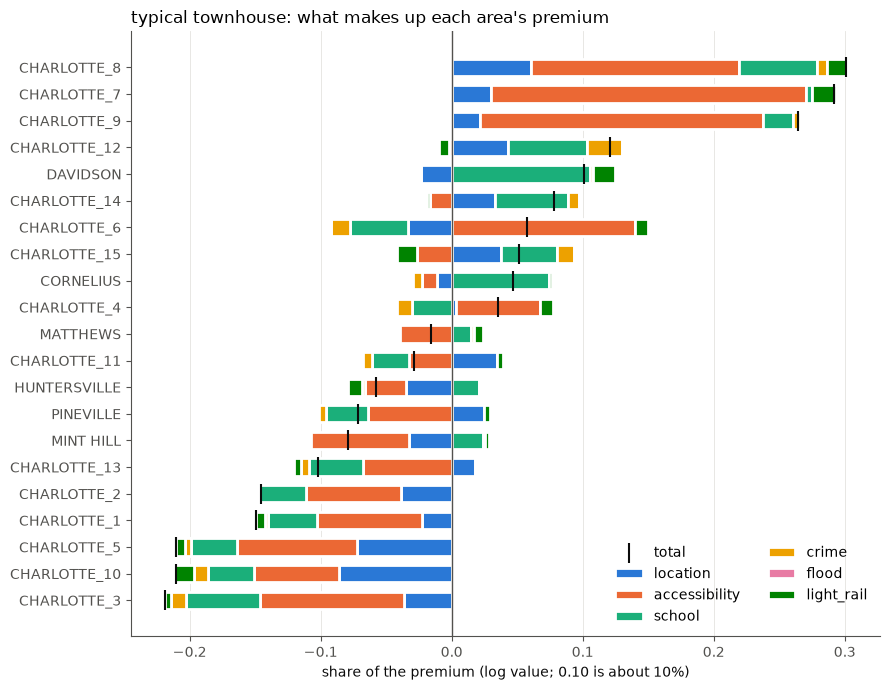

,premium,log_premium,location_log,accessibility_log,school_log,crime_log,flood_log,light_rail_log
area,,,,,,,,
CHARLOTTE_3,-0.197,-0.219,-0.037,-0.109,-0.057,-0.011,0.0,-0.005
CHARLOTTE_10,-0.190,-0.211,-0.086,-0.065,-0.036,-0.010,0.0,-0.014
CHARLOTTE_5,-0.190,-0.210,-0.072,-0.092,-0.035,-0.005,0.0,-0.007
CHARLOTTE_1,-0.139,-0.150,-0.023,-0.080,-0.038,-0.002,0.0,-0.007
CHARLOTTE_2,-0.135,-0.145,-0.038,-0.073,-0.036,0.000,0.0,0.001
CHARLOTTE_13,-0.097,-0.102,0.018,-0.068,-0.041,-0.006,0.0,-0.005
MINT HILL,-0.076,-0.079,-0.032,-0.075,0.024,0.001,0.0,0.003
PINEVILLE,-0.069,-0.072,0.025,-0.064,-0.032,-0.005,0.0,0.005
HUNTERSVILLE,-0.056,-0.058,-0.035,-0.031,0.021,-0.003,0.0,-0.010


In [6]:
plot_decomposition("typical townhouse")

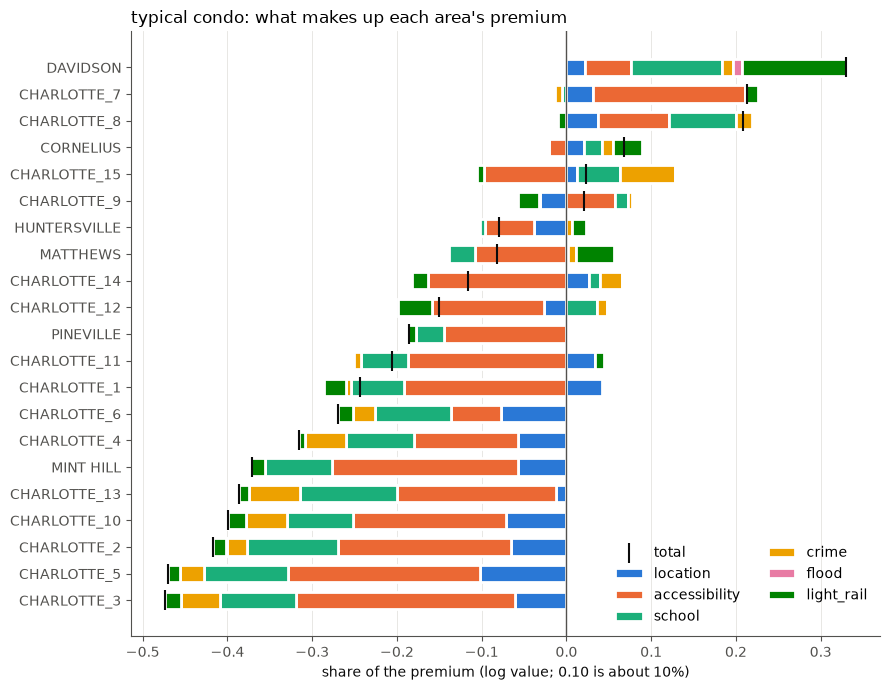

,premium,log_premium,location_log,accessibility_log,school_log,crime_log,flood_log,light_rail_log
area,,,,,,,,
CHARLOTTE_3,-0.377,-0.474,-0.060,-0.259,-0.089,-0.046,-0.000,-0.018
CHARLOTTE_5,-0.375,-0.470,-0.102,-0.227,-0.099,-0.028,-0.000,-0.014
CHARLOTTE_2,-0.341,-0.417,-0.065,-0.204,-0.107,-0.025,-0.000,-0.016
CHARLOTTE_10,-0.329,-0.399,-0.072,-0.180,-0.078,-0.048,0.000,-0.021
CHARLOTTE_13,-0.320,-0.386,-0.013,-0.187,-0.114,-0.060,0.000,-0.012
MINT HILL,-0.310,-0.371,-0.057,-0.219,-0.080,0.001,0.000,-0.016
CHARLOTTE_4,-0.271,-0.316,-0.057,-0.123,-0.081,-0.048,-0.000,-0.007
CHARLOTTE_6,-0.236,-0.270,-0.078,-0.058,-0.090,-0.026,-0.000,-0.018
CHARLOTTE_1,-0.216,-0.244,0.042,-0.192,-0.063,-0.005,-0.001,-0.026


In [7]:
plot_decomposition("typical condo")

## What this shows

1. **The same house is worth more than twice as much in the most expensive area as in the cheapest.** The typical
   single-family house (2,125 sq ft, assessed $465,500 in Matthews) would be assessed at about $325,000 in
   CHARLOTTE_3 (−25% against a typical county location) and about $713,000 in CHARLOTTE_9 (+70%). Eight areas are
   above the county and thirteen below.
2. **The model agrees with the raw data.** Across areas, the model's premium correlates 0.88 to 0.95 with the
   raw-data premium (price per sq ft of similar-sized houses), for every reference house. The model's spread is a
   little wider at the low end (CHARLOTTE_3: −25% against −12% raw) and narrower for CHARLOTTE_7 (+40% against
   +78% raw). Pineville is the one area where the two disagree in sign (−10% against +8% raw).
3. **The two production models give almost the same premiums** (for the typical single-family house, the largest
   gap is 3.6 points, Cornelius). The
   neighborhood price isn't needed to place a house: the other location features carry the same information.
4. **Where the premium comes from depends on the kind of area** (typical single-family house, without the
   neighborhood price):
   - **Central Charlotte (CHARLOTTE_7, 8, 9): accessibility.** It is +0.30 to +0.33 in log value (about +35%) of
     premiums of +40% to +70%. Schools add up to +0.11.
   - **Lake and suburban areas (Davidson, Cornelius, CHARLOTTE_12, 14, 15): schools.** They are +0.06 to +0.19
     of premiums of +14% to +29%, with accessibility close to 0.
   - **Below-county areas: mostly accessibility.** It is negative in all of them but CHARLOTTE_6 (−0.02 to −0.12).
     Schools pull the Charlotte areas and Pineville down further (−0.02 to −0.09), but they lift Matthews,
     Huntersville and Mint Hill (+0.02 to +0.04).
   - **The `location` group itself is small** (−0.07 to +0.11). The `area` label, coordinates and neighborhood
     sales add little once accessibility and schools are known. Crime is at most ±0.05, and the flood zone is 0.
   - **Light rail gives Cornelius +0.076, but Cornelius has no light rail.** The distance to the light rail is
     standing in for distance from the city, or for the lake. Read it as location, not transit.
5. **The premium is not one number per area: it depends on the type of house.** For the typical condo, Davidson
   is +43% and CHARLOTTE_9 only +3%. For the typical single-family house, CHARLOTTE_9 is +70%. Each type is
   compared with its own typical county location, so read each row's pattern, not its level against other rows.
6. **For single-family houses, the premium is about the same percent at different sizes.** Abbey Hill (2,596 sq
   ft), Seton House (4,056) and Kelly Woods (5,249) have premiums close to the typical house's in most areas. For
   Kelly Woods, nine of the below-county areas are marked `*`: few houses that large there, so those numbers are
   extrapolations.

**Limits**
- The estimates are 2023 assessed values, not market prices.
- The decomposition mixes groups from two parcels, which gives combinations no real house has. Read the shares as
  the model's attribution, not as what a house would be worth if only its schools changed.
- Crime rates cover Charlotte only. The towns get the county median, so their crime share is close to 0 by
  construction.
- Donors are a sample of 300 parcels per area (Pineville and Davidson have fewer houses of some types), so small
  differences between areas (a few points) are within sampling noise.
